## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Core Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## Inspect Model Files in Drive

In [3]:
import os

dataset_folder = "/content/drive/MyDrive/carla_dataset"

for current_dir, _, file_list in os.walk(dataset_folder):
    for filename in file_list:
        if filename.endswith(".pth"):
            print(os.path.join(current_dir, filename))

/content/drive/MyDrive/carla_dataset/traffic_light_model.pth
/content/drive/MyDrive/carla_dataset/pedestrian_model.pth
/content/drive/MyDrive/carla_dataset/vehicle_model.pth


## List Dataset Contents

In [4]:
import os

print(os.listdir("/content/drive/MyDrive/carla_dataset"))

['test.zip', 'train.zip', 'validation.zip', 'train', 'test', 'validation', 'test-fog.zip', 'test-night.zip', 'test-town-01.zip', 'traffic_light_model.pth', 'pedestrian_model.pth', 'vehicle_model.pth']


## Unzip Datasets

In [5]:
from pathlib import Path
import zipfile

source_folder = Path("/content/drive/MyDrive/carla_dataset")
destination = Path("/content")

archives = ["train.zip", "validation.zip", "test.zip"]

for archive in archives:
    archive_path = source_folder / archive
    output_folder = destination / archive.replace(".zip", "")

    with zipfile.ZipFile(archive_path, mode="r") as compressed_file:
        compressed_file.extractall(output_folder)

    print(f"Extracted {archive} -> {output_folder}")

Extracted train.zip -> /content/train
Extracted validation.zip -> /content/validation
Extracted test.zip -> /content/test


## Locate `labels.csv`

In [6]:
import os

search_directory = "/content/test"

for current_folder, _, file_names in os.walk(search_directory):
    if "labels.csv" in file_names:
        print(current_folder)

/content/test/test


## Load and Display Test Labels

In [7]:
from pathlib import Path
import pandas as pd

labels_file = Path("/content/test/test/labels.csv")

labels_df = pd.read_csv(labels_file)

display(labels_df.head())

print("\nAvailable Columns:")
print(labels_df.columns.tolist())

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,False,15,0,35
1,10,True,False,True,299,0,116
2,20,True,False,True,298,0,307
3,30,True,False,True,297,0,258
4,40,True,False,True,297,0,249



Available Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


## List Test Images

In [8]:
from pathlib import Path

image_dir = Path("/content/test/test/rgb-front")

image_list = [img.name for img in image_dir.iterdir() if img.is_file()]

print(f"Number of images: {len(image_list)}")
print("First 5 images:")
print(image_list[:5])

Number of images: 3600
First 5 images:
['020950.jpg', '025220.jpg', '035930.jpg', '006570.jpg', '026290.jpg']


## Load Labels (Re-read)

In [9]:
import pandas as pd

labels = pd.read_csv("/content/test/test/labels.csv")

## Format Frame Column

In [10]:
labels["frame"] = labels["frame"].apply(lambda x: f"{int(x):06d}.jpg")

print(
    labels[[
        "frame",
        "has_traffic_light",
        "has_pedestrian",
        "has_vehicle"
    ]].head()
)

        frame  has_traffic_light  has_pedestrian  has_vehicle
0  000000.jpg              False           False        False
1  000010.jpg               True           False         True
2  000020.jpg               True           False         True
3  000030.jpg               True           False         True
4  000040.jpg               True           False         True


## Count Positive Labels

In [11]:
target_columns = [
    "has_traffic_light",
    "has_pedestrian",
    "has_vehicle"
]

for column in target_columns:
    count = labels[column].sum()
    print(f"{column.replace('has_', '').replace('_', ' ').title()} positives: {count}")

Traffic Light positives: 2584
Pedestrian positives: 706
Vehicle positives: 2700


## Import PyTorch Modules

In [12]:
import torch
import torch.nn as nn

## Load Traffic Light Model Checkpoint (Inspection)

In [13]:
from pathlib import Path
import torch

model_path = Path("/content/drive/MyDrive/carla_dataset/traffic_light_model.pth")

checkpoint = torch.load(model_path, map_location=torch.device("cpu"))

print(checkpoint.keys())

odict_keys(['model.0.weight', 'model.0.bias', 'model.3.weight', 'model.3.bias', 'model.6.weight', 'model.6.bias', 'model.10.weight', 'model.10.bias', 'model.12.weight', 'model.12.bias'])


## Define and Load Traffic Light Detector

In [14]:
import torch
from torch import nn
from pathlib import Path

class TrafficLightDetector(nn.Module):
    def __init__(self):
        super().__init__()

        layers = [
            nn.Conv2d(3, 16, 3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3),
            nn.ReLU(inplace=True),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        ]

        self.model = nn.Sequential(*layers)   # <-- Keep this name

    def forward(self, x):
        return self.model(x)


traffic_light_model = TrafficLightDetector()

checkpoint = torch.load(
    Path("/content/drive/MyDrive/carla_dataset/traffic_light_model.pth"),
    map_location="cpu"
)

traffic_light_model.load_state_dict(checkpoint)

traffic_light_model.eval()

print("Traffic Light Model Loaded")

Traffic Light Model Loaded


## Define and Load Vehicle Detector

In [15]:
from pathlib import Path
import torch
from torch import nn


class VehicleDetector(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        )

    def forward(self, inputs):
        return self.model(inputs)


checkpoint_path = Path("/content/drive/MyDrive/carla_dataset/vehicle_model.pth")

vehicle_model = VehicleDetector()

weights = torch.load(checkpoint_path, map_location=torch.device("cpu"))
vehicle_model.load_state_dict(weights)

vehicle_model.eval()

print("Vehicle Model Loaded")

Vehicle Model Loaded


## Define and Load Pedestrian Detector

In [16]:
from pathlib import Path
import torch
from torch import nn


class PedestrianDetector(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(16, 32, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3),
            nn.ReLU(inplace=True),

            nn.Flatten(),
            nn.Identity(),

            nn.Linear(50176, 128),
            nn.ReLU(inplace=True),

            nn.Linear(128, 1)
        )

    def forward(self, image):
        return self.model(image)


model_file = Path("/content/drive/MyDrive/carla_dataset/pedestrian_model.pth")

pedestrian_model = PedestrianDetector()

model_weights = torch.load(model_file, map_location=torch.device("cpu"))
pedestrian_model.load_state_dict(model_weights)

pedestrian_model.eval()

print("Pedestrian Model Loaded")

Pedestrian Model Loaded


## Define Image Transformation

In [17]:
from torchvision.transforms import Compose, Resize, ToTensor

transform_128 = Compose([
    Resize(size=(128, 128)),
    ToTensor()
])

## Expected Calibration Error (ECE) Function

In [18]:
import numpy as np

def compute_ece(conf_scores, pred_labels, true_labels, num_bins=10):
    conf_scores = np.asarray(conf_scores)
    pred_labels = np.asarray(pred_labels)
    true_labels = np.asarray(true_labels)

    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    expected_error = 0.0

    for lower_edge, upper_edge in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (conf_scores >= lower_edge) & (conf_scores < upper_edge)

        if not np.any(in_bin):
            continue

        accuracy = np.mean(pred_labels[in_bin] == true_labels[in_bin])
        average_confidence = conf_scores[in_bin].mean()
        proportion = in_bin.mean()

        expected_error += proportion * abs(accuracy - average_confidence)

    return expected_error

## Evaluate Traffic Light ECE (Manual Calculation)

In [19]:
from pathlib import Path
from PIL import Image
import torch

confidence_scores = []
predicted_labels = []
actual_labels = []

test_images = Path("/content/test/test/rgb-front")

for sample in labels.itertuples(index=False):

    image_file = test_images / sample.frame

    image = Image.open(image_file).convert("RGB")

    input_tensor = transform_128(image).unsqueeze(0)

    with torch.inference_mode():
        confidence = torch.sigmoid(
            traffic_light_model(input_tensor)
        ).item()

    predicted_class = int(confidence > 0.5)

    confidence_scores.append(confidence)
    predicted_labels.append(predicted_class)
    actual_labels.append(int(sample.has_traffic_light))

traffic_light_ece = compute_ece(
    confidence_scores,
    predicted_labels,
    actual_labels
)

print(f"Traffic Light ECE = {traffic_light_ece}")

Traffic Light ECE = 0.16489018737157396


## General Model ECE Evaluation Function

In [20]:
from pathlib import Path
from PIL import Image
import torch

def evaluate_model_ece(model, target_column):

    confidence_scores = []
    predicted_classes = []
    true_classes = []

    image_directory = Path("/content/test/test/rgb-front")

    for sample in labels.itertuples(index=False):

        image = Image.open(image_directory / sample.frame).convert("RGB")

        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            confidence = torch.sigmoid(model(input_tensor)).item()

        predicted_label = int(confidence > 0.5)

        confidence_scores.append(confidence)
        predicted_classes.append(predicted_label)
        true_classes.append(int(getattr(sample, target_column)))

    return compute_ece(
        confidence_scores,
        predicted_classes,
        true_classes
    )

## Evaluate Traffic Light ECE

In [21]:
traffic_light_ece = evaluate_model_ece(
    model=traffic_light_model,
    target_column="has_traffic_light"
)

print(f"Traffic Light ECE: {traffic_light_ece}")

Traffic Light ECE: 0.16489018737157396


## Evaluate Vehicle ECE

In [22]:
vehicle_calibration = evaluate_model_ece(
    model=vehicle_model,
    target_column="has_vehicle"
)

print(f"Vehicle ECE: {vehicle_calibration}")

Vehicle ECE: 0.11771381622801222


## Evaluate Pedestrian ECE

In [23]:
pedestrian_calibration = evaluate_model_ece(
    model=pedestrian_model,
    target_column="has_pedestrian"
)

print(f"Pedestrian ECE: {pedestrian_calibration}")

Pedestrian ECE: 0.5738435489318282


## Reliability Diagram Function

In [24]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import torch


def reliability_diagram(model, target_column, model_name):

    confidence_scores = []
    predicted_labels = []
    true_labels = []

    image_directory = Path("/content/test/test/rgb-front")

    for sample in labels.itertuples(index=False):

        image = Image.open(image_directory / sample.frame).convert("RGB")

        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():
            confidence = torch.sigmoid(model(input_tensor)).item()

        confidence_scores.append(confidence)
        predicted_labels.append(int(confidence > 0.5))
        true_labels.append(int(getattr(sample, target_column)))

    confidence_scores = np.asarray(confidence_scores)
    predicted_labels = np.asarray(predicted_labels)
    true_labels = np.asarray(true_labels)

    bin_edges = np.linspace(0.0, 1.0, 11)

    average_confidence = []
    average_accuracy = []

    for start, end in zip(bin_edges[:-1], bin_edges[1:]):

        in_bin = (confidence_scores >= start) & (confidence_scores < end)

        if not np.any(in_bin):
            average_confidence.append((start + end) / 2)
            average_accuracy.append(0)
            continue

        average_confidence.append(confidence_scores[in_bin].mean())
        average_accuracy.append(
            (predicted_labels[in_bin] == true_labels[in_bin]).mean()
        )

    plt.figure(figsize=(6, 6))

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.plot(
        average_confidence,
        average_accuracy,
        marker="o"
    )

    plt.xlabel("Confidence")
    plt.ylabel("Accuracy")
    plt.title(f"Reliability Diagram - {model_name}")

    plt.show()

## Plot Traffic Light Reliability Diagram

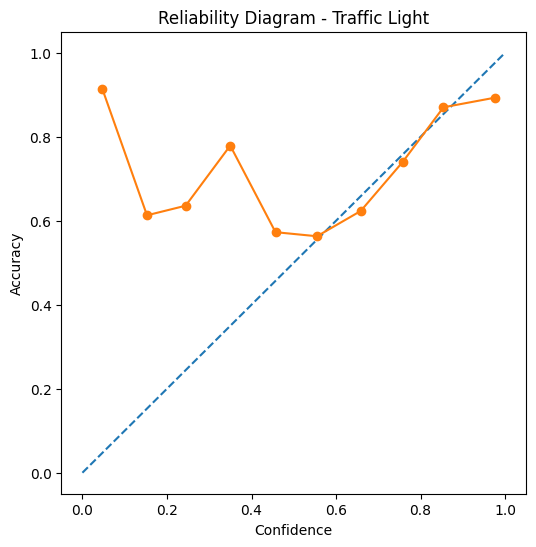

In [25]:
reliability_diagram(
    model=traffic_light_model,
    target_column="has_traffic_light",
    model_name="Traffic Light"
)

## Plot Vehicle Reliability Diagram

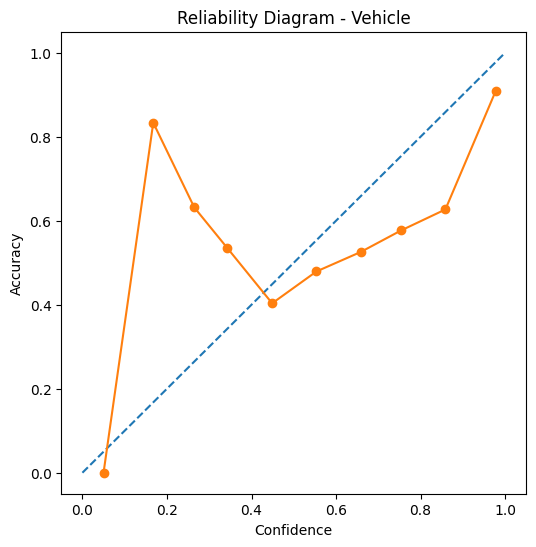

In [26]:
reliability_diagram(
    model=vehicle_model,
    target_column="has_vehicle",
    model_name="Vehicle"
)

## Plot Pedestrian Reliability Diagram

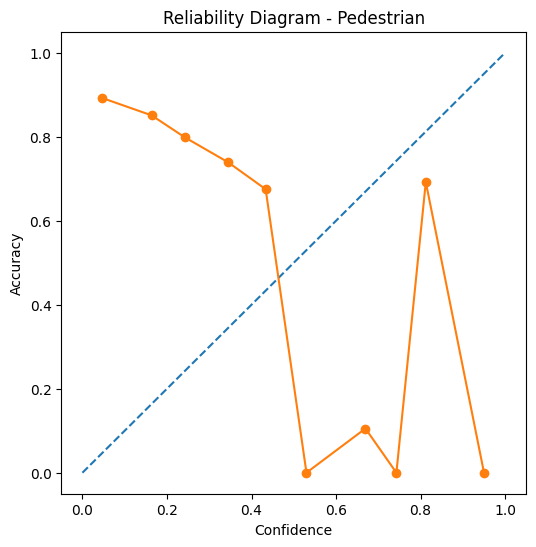

In [27]:
reliability_diagram(
    model=pedestrian_model,
    target_column="has_pedestrian",
    model_name="Pedestrian"
)

## Explore Validation Folder

In [28]:
from pathlib import Path

validation_folder = Path("/content/validation")

for directory in validation_folder.rglob("*"):
    if directory.is_dir() and (directory / "labels.csv").exists():
        print(directory)

/content/validation/validation


## Load Validation Labels

In [29]:
from pathlib import Path
import pandas as pd

validation_csv = Path("/content/validation/validation/labels.csv")

validation_labels = pd.read_csv(validation_csv)

display(validation_labels.head())

print("\nAvailable Columns:")
print(validation_labels.columns.tolist())

print(f"\nTotal validation images: {len(validation_labels)}")

,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,True,False,0,178,10
1,10,True,False,False,347,0,2
2,20,True,False,False,347,0,0
3,30,True,False,False,347,0,0
4,40,True,False,False,347,0,0



Available Columns:
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']

Total validation images: 3600


## Define Image Transformation (Validation)

In [30]:
from torchvision.transforms import Compose, Resize, ToTensor

transform_128 = Compose(
    [
        Resize((128, 128)),
        ToTensor()
    ]
)

## Compute Validation Negative Log-Likelihood (NLL) Function

In [31]:
from pathlib import Path
import torch
import torch.nn.functional as F
from PIL import Image

validation_directory = Path("/content/validation/validation/rgb-front")


def compute_validation_nll(model, target_column, temperature):

    cumulative_loss = 0.0
    sample_count = 0

    for sample in val_labels.itertuples(index=False):

        image_file = validation_directory / f"{int(sample.frame):06d}.jpg"

        image = Image.open(image_file).convert("RGB")

        input_tensor = transform_128(image).unsqueeze(0)

        target_tensor = torch.tensor(
            [[float(getattr(sample, target_column))]],
            dtype=torch.float32
        )

        with torch.inference_mode():

            logits = model(input_tensor)
            adjusted_logits = logits / temperature

            batch_loss = F.binary_cross_entropy_with_logits(
                adjusted_logits,
                target_tensor
            )

        cumulative_loss += batch_loss.item()
        sample_count += 1

    return cumulative_loss / sample_count

## Load Validation Labels (Re-read)

In [35]:
import pandas as pd

val_labels = pd.read_csv(
    "/content/validation/validation/labels.csv"
)

print(val_labels.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False            True        False                 0   
1     10               True           False        False               347   
2     20               True           False        False               347   
3     30               True           False        False               347   
4     40               True           False        False               347   

   px_pedestrian  px_vehicle  
0            178          10  
1              0           2  
2              0           0  
3              0           0  
4              0           0  


## Find Optimal Temperature for Traffic Light Model

In [36]:
temperature_values = np.arange(0.5, 3.1, 0.1)

optimal_temperature = None
lowest_nll = float("inf")

for temperature in temperature_values:

    current_nll = compute_validation_nll(
        model=traffic_light_model,
        target_column="has_traffic_light",
        temperature=temperature
    )

    print(f"T = {temperature:.1f}  NLL = {current_nll:.6f}")

    if current_nll < lowest_nll:
        lowest_nll = current_nll
        optimal_temperature = temperature

print(f"\nBest Temperature = {optimal_temperature:.1f}")
print(f"Best NLL = {lowest_nll}")

T = 0.5  NLL = 0.416749
T = 0.6  NLL = 0.378151
T = 0.7  NLL = 0.354847
T = 0.8  NLL = 0.340890
T = 0.9  NLL = 0.332965
T = 1.0  NLL = 0.329083
T = 1.1  NLL = 0.327984
T = 1.2  NLL = 0.328841
T = 1.3  NLL = 0.331085
T = 1.4  NLL = 0.334323
T = 1.5  NLL = 0.338270
T = 1.6  NLL = 0.342722
T = 1.7  NLL = 0.347526
T = 1.8  NLL = 0.352568
T = 1.9  NLL = 0.357764
T = 2.0  NLL = 0.363048
T = 2.1  NLL = 0.368370
T = 2.2  NLL = 0.373693
T = 2.3  NLL = 0.378987
T = 2.4  NLL = 0.384230
T = 2.5  NLL = 0.389405
T = 2.6  NLL = 0.394500
T = 2.7  NLL = 0.399505
T = 2.8  NLL = 0.404414
T = 2.9  NLL = 0.409220
T = 3.0  NLL = 0.413923

Best Temperature = 1.1
Best NLL = 0.32798446325682207


## Find Optimal Temperature for Vehicle Model

In [37]:
temperature_values = np.arange(0.5, 3.1, 0.1)

optimal_vehicle_temperature = None
minimum_vehicle_nll = float("inf")

for temperature in temperature_values:

    validation_nll = compute_validation_nll(
        model=vehicle_model,
        target_column="has_vehicle",
        temperature=temperature
    )

    print(f"T = {temperature:.1f}  NLL = {validation_nll:.6f}")

    if validation_nll < minimum_vehicle_nll:
        minimum_vehicle_nll = validation_nll
        optimal_vehicle_temperature = temperature

print(f"\nBest Temperature = {optimal_vehicle_temperature:.1f}")
print(f"Best NLL = {minimum_vehicle_nll}")

T = 0.5  NLL = 1.235127
T = 0.6  NLL = 1.059980
T = 0.7  NLL = 0.939055
T = 0.8  NLL = 0.851678
T = 0.9  NLL = 0.786414
T = 1.0  NLL = 0.736442
T = 1.1  NLL = 0.697443
T = 1.2  NLL = 0.666552
T = 1.3  NLL = 0.641800
T = 1.4  NLL = 0.621787
T = 1.5  NLL = 0.605496
T = 1.6  NLL = 0.592167
T = 1.7  NLL = 0.581226
T = 1.8  NLL = 0.572228
T = 1.9  NLL = 0.564826
T = 2.0  NLL = 0.558746
T = 2.1  NLL = 0.553768
T = 2.2  NLL = 0.549713
T = 2.3  NLL = 0.546436
T = 2.4  NLL = 0.543817
T = 2.5  NLL = 0.541757
T = 2.6  NLL = 0.540174
T = 2.7  NLL = 0.538999
T = 2.8  NLL = 0.538173
T = 2.9  NLL = 0.537646
T = 3.0  NLL = 0.537377

Best Temperature = 3.0
Best NLL = 0.5373765078998662


## Find Optimal Temperature for Pedestrian Model

In [38]:
temperature_values = np.arange(0.5, 3.1, 0.1)

optimal_pedestrian_temperature = None
minimum_pedestrian_nll = float("inf")

for temperature in temperature_values:

    validation_nll = compute_validation_nll(
        model=pedestrian_model,
        target_column="has_pedestrian",
        temperature=temperature
    )

    print(f"T = {temperature:.1f}  NLL = {validation_nll:.6f}")

    if validation_nll < minimum_pedestrian_nll:
        minimum_pedestrian_nll = validation_nll
        optimal_pedestrian_temperature = temperature

print(f"\nBest Temperature = {optimal_pedestrian_temperature:.1f}")
print(f"Best NLL = {minimum_pedestrian_nll}")

T = 0.5  NLL = 0.776360
T = 0.6  NLL = 0.704779
T = 0.7  NLL = 0.661824
T = 0.8  NLL = 0.635342
T = 0.9  NLL = 0.618819
T = 1.0  NLL = 0.608546
T = 1.1  NLL = 0.602309
T = 1.2  NLL = 0.598737
T = 1.3  NLL = 0.596954
T = 1.4  NLL = 0.596385
T = 1.5  NLL = 0.596645
T = 1.6  NLL = 0.597473
T = 1.7  NLL = 0.598687
T = 1.8  NLL = 0.600159
T = 1.9  NLL = 0.601799
T = 2.0  NLL = 0.603543
T = 2.1  NLL = 0.605345
T = 2.2  NLL = 0.607172
T = 2.3  NLL = 0.609000
T = 2.4  NLL = 0.610812
T = 2.5  NLL = 0.612596
T = 2.6  NLL = 0.614344
T = 2.7  NLL = 0.616051
T = 2.8  NLL = 0.617712
T = 2.9  NLL = 0.619325
T = 3.0  NLL = 0.620890

Best Temperature = 1.4
Best NLL = 0.5963848292744822


## Scaled ECE Evaluation Function

In [39]:
from pathlib import Path
from PIL import Image
import torch

def evaluate_model_ece_scaled(model, target_column, temperature):

    confidence_scores = []
    predicted_classes = []
    true_classes = []

    image_directory = Path("/content/test/test/rgb-front")

    for sample in labels.itertuples(index=False):

        image = Image.open(image_directory / sample.frame).convert("RGB")

        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():

            logits = model(input_tensor)
            calibrated_logits = logits / temperature

            confidence = torch.sigmoid(calibrated_logits).item()

        predicted_label = int(confidence > 0.5)

        confidence_scores.append(confidence)
        predicted_classes.append(predicted_label)
        true_classes.append(int(getattr(sample, target_column)))

    return compute_ece(
        confidence_scores,
        predicted_classes,
        true_classes
    )

## Evaluate Scaled Traffic Light ECE

In [40]:
scaled_traffic_ece = evaluate_model_ece_scaled(
    model=traffic_light_model,
    target_column="has_traffic_light",
    temperature=3.0
)

print(f"Traffic Light Scaled ECE = {scaled_traffic_ece}")

Traffic Light Scaled ECE = 0.1651694501419034


## Evaluate Scaled Vehicle ECE

In [41]:
scaled_vehicle_ece = evaluate_model_ece_scaled(
    model=vehicle_model,
    target_column="has_vehicle",
    temperature=2.5
)

print(f"Vehicle Scaled ECE = {scaled_vehicle_ece}")

Vehicle Scaled ECE = 0.041061194323831124


## Evaluate Scaled Pedestrian ECE

In [42]:
scaled_pedestrian_ece = evaluate_model_ece_scaled(
    model=pedestrian_model,
    target_column="has_pedestrian",
    temperature=1.6
)

print(f"Pedestrian Scaled ECE = {scaled_pedestrian_ece}")

Pedestrian Scaled ECE = 0.4924607107777977


## Check Required Objects in Global Scope

In [43]:
required_objects = [
    "pedestrian_model",
    "labels",
    "transform_128"
]

for obj in required_objects:
    print(obj in globals())

True
True
True


## Define Cost Function

In [44]:
from pathlib import Path
from PIL import Image
import torch

def compute_cost(model, threshold, label_column, temperature=None):

    false_negatives = 0
    false_positives = 0

    image_directory = Path("/content/test/test/rgb-front")

    for sample in labels.itertuples(index=False):

        image = Image.open(image_directory / sample.frame).convert("RGB")

        input_tensor = transform_128(image).unsqueeze(0)

        with torch.inference_mode():

            logits = model(input_tensor)

            if temperature is not None:
                logits = logits / temperature

            confidence = torch.sigmoid(logits).item()

        predicted_label = int(confidence >= threshold)
        actual_label = int(getattr(sample, label_column))

        if actual_label and not predicted_label:
            false_negatives += 1
        elif not actual_label and predicted_label:
            false_positives += 1

    total_cost = (100 * false_negatives) + false_positives

    return false_negatives, false_positives, total_cost

## Compute Pedestrian Cost (Default Threshold)

In [45]:
false_negatives, false_positives, total_cost = compute_cost(
    model=pedestrian_model,
    threshold=0.5,
    label_column="has_pedestrian"
)

print(f"FN = {false_negatives}")
print(f"FP = {false_positives}")
print(f"Loss = {total_cost}")

FN = 686
FP = 50
Loss = 68650


## Compute Pedestrian Cost (Optimized Threshold)

In [46]:
optimized_fn, optimized_fp, optimized_loss = compute_cost(
    model=pedestrian_model,
    threshold=0.0099,
    label_column="has_pedestrian"
)

print(f"FN = {optimized_fn}")
print(f"FP = {optimized_fp}")
print(f"Loss = {optimized_loss}")

FN = 6
FP = 2816
Loss = 3416


## Compute Pedestrian Cost (Calibrated, Default Threshold)

In [47]:
calibrated_fn, calibrated_fp, calibrated_loss = compute_cost(
    model=pedestrian_model,
    threshold=0.5,
    label_column="has_pedestrian",
    temperature=1.6
)

print(f"FN = {calibrated_fn}")
print(f"FP = {calibrated_fp}")
print(f"Loss = {calibrated_loss}")

FN = 686
FP = 50
Loss = 68650


## Compute Pedestrian Cost (Calibrated, Optimized Threshold)

In [48]:
final_fn, final_fp, final_loss = compute_cost(
    model=pedestrian_model,
    threshold=0.0099,
    label_column="has_pedestrian",
    temperature=1.6
)

print(f"FN = {final_fn}")
print(f"FP = {final_fp}")
print(f"Loss = {final_loss}")

FN = 0
FP = 2894
Loss = 2894
